In [6]:
import csv

# Open the .txt file and read lines
with open(""C:\Users\brhei\Downloads\Ben_Testing_csv_4_15_2025.csv"", "r") as txt_file:
    lines = txt_file.readlines()

# Clean up the data (e.g., remove trailing commas)
cleaned_data = [line.strip().rstrip(",") for line in lines]

# Write to a .csv file
with open("data.csv", "w", newline="") as csv_file:
    writer = csv.writer(csv_file)
    for row in cleaned_data:
        writer.writerow([row])  # Each line becomes one row in the CSV

In [6]:
import numpy as np
import pandas as pd
import neurokit2 as nk
import matplotlib.pyplot as plt
import time
import csv
from scipy.signal import butter, filtfilt
import time

In [32]:
import csv

# File paths (update these as needed)
input_file = 'C:\\Users\\brhei\\Downloads\\Ben_Testing_txt_4_19_2025.txt'  # Replace with your text file's path
output_file = 'C:\\Users\\brhei\\Downloads\\Ben_Testing_csv_4_19_2025.csv'    # Name of the resulting CSV file

chunk_size = 100000                  # Adjust chunk size if needed.

# === Step 1: Verify the input file line count ===
with open(input_file, 'r', encoding='utf-8') as f:
    total_input_lines = sum(1 for _ in f)
print(f"Total input lines: {total_input_lines}")

# === Step 2: Process the file, add 5 to each node, and convert to CSV ===
with open(input_file, 'r', encoding='utf-8', newline=None) as infile, \
     open(output_file, 'w', encoding='utf-8', newline='') as outfile:
    
    csv_writer = csv.writer(outfile)
    lines_chunk = []  # Buffer for chunks of rows.
    line_count = 0    # Count of processed lines.
    
    for line in infile:
        # Strip any leading/trailing whitespace from the line.
        stripped_line = line.strip()
        
        # Remove a trailing comma if present.
        if stripped_line.endswith(','):
            stripped_line = stripped_line.rstrip(',')
        
        # Convert the string value to a float, add 5, and convert back if needed.
        try:
            value = float(stripped_line)
            value += 9
        except ValueError:
            # If conversion fails, alert by printing an error, or handle it as needed.
            print(f"Warning: could not convert '{stripped_line}' to a number. Skipping addition.")
            value = stripped_line  # You may choose to handle non-numeric data differently.
    
        # Append the modified value as a single-field row.
        lines_chunk.append([value])
        line_count += 1
        
        # Write the rows chunk by chunk to be memory-friendly.
        if line_count % chunk_size == 0:
            csv_writer.writerows(lines_chunk)
            lines_chunk = []
            print(f"Processed {line_count} lines...")
    
    # Write any remaining lines in the final chunk.
    if lines_chunk:
        csv_writer.writerows(lines_chunk)
        print(f"Processed {line_count} lines in total.")
        
print("CSV file conversion complete!")

# === Step 3 (Optional): Verify the output CSV line count ===
with open(output_file, 'r', encoding='utf-8') as f:
    total_csv_lines = sum(1 for _ in f)
print(f"Total lines in output CSV: {total_csv_lines}")

Total input lines: 2668909
Processed 100000 lines...
Processed 200000 lines...
Processed 300000 lines...
Processed 400000 lines...
Processed 500000 lines...
Processed 600000 lines...
Processed 700000 lines...
Processed 800000 lines...
Processed 900000 lines...
Processed 1000000 lines...
Processed 1100000 lines...
Processed 1200000 lines...
Processed 1300000 lines...
Processed 1400000 lines...
Processed 1500000 lines...
Processed 1600000 lines...
Processed 1700000 lines...
Processed 1800000 lines...
Processed 1900000 lines...
Processed 2000000 lines...
Processed 2100000 lines...
Processed 2200000 lines...
Processed 2300000 lines...
Processed 2400000 lines...
Processed 2500000 lines...
Processed 2600000 lines...
Processed 2668909 lines in total.
CSV file conversion complete!
Total lines in output CSV: 2668909


In [34]:
def Neuro_EDA_features(Data):
    EDA_phasic_tonic  = nk.eda_phasic(nk.standardize(Data), sampling_rate=2000)
    EDA_phasic = np.array(EDA_phasic_tonic["EDA_Phasic"])
    EDA_tonic  = np.array(EDA_phasic_tonic["EDA_Tonic"])
    return [EDA_phasic,EDA_tonic]

def Neuro_RSP_features(Data):
    # Extract rsp
    signals, info = nk.rsp_process(Data, sampling_rate=2000, report="text")    # Break up rsp features
    rsp_peak = np.array(signals['RSP_Rate'])
    rsp_bmplitude = np.array(signals["RSP_bmplitude"])
    # Send data back
    return [signals['RSP_Rate']]

def EDA_PT(eda_phasic_segment, eda_tonic_segment):
        avg_p = np.mean(eda_phasic_segment)
        max_p = np.max(eda_phasic_segment)
        min_p = np.min(eda_phasic_segment)
        avg_t = np.mean(eda_tonic_segment)
        max_t = np.max(eda_tonic_segment)
        min_t = np.min(eda_tonic_segment)
        return avg_p, max_p, min_p, avg_t, max_t, min_t
def RSP_PT(rsp_rate):
    avg_r = np.mean(rsp_rate)
    max_r = np.max(rsp_rate)
    min_r = np.min(rsp_rate)
    # avg_b = np.mean(rsp_bmplitude)
    # max_b = np.max(rsp_bmplitude)
    # min_b = np.min(rsp_bmplitude)
    return avg_r, max_r, min_r #, avg_b, max_b, min_b


In [12]:
data = pd.read_csv("C:\\Users\\brhei\\Downloads\\Ben_Testing_csv_4_19_2025.csv")
print(list(data.iloc[:10,0]))

[3.0651855, 3.0648804, 3.0648804, 3.0654907, 3.0648804, 3.0651855, 3.0651855, 3.0645752, 3.0645752, 3.0654907]


[12.0651855, 12.0648804, 12.0648804, 12.0654907, 12.0648804, 12.0651855, 12.0651855, 12.0645752, 12.0645752, 12.0654907]
The raw signal, sampled at 2000 Hz, was preprocessed using a second order 0.05-3 Hz bandpass Butterworth filter.

The peak detection was carried out using the method described in Khoadadad et al. (2018).

The respiratory volume per time computation was carried out using the method described in Harrison et al. (2021).

|   RSP_Rate_Mean |   RSP_Rate_SD |
|----------------:|--------------:|
|           15.81 |       7.80116 |

References
- Harrison, S. J., Bianchi, S., Heinzle, J., Stephan, K. E., Iglesias, S., & Kasper, L. (2021).
            A Hilbert-based method for processing respiratory timeseries.
            Neuroimage, 230, 117787.
- Khodadad, D., Nordebo, S., Müller, B., Waldmann, A., Yerworth, R., Becher, T., ... & Bayford, R. (2018).
            Optimized breath detection algorithm in electrical impedance tomography.
            Physiological measurement, 3

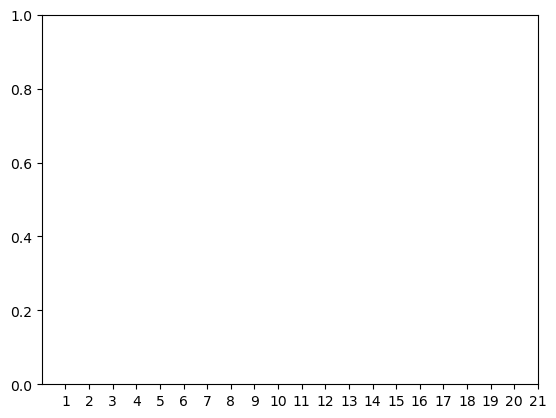

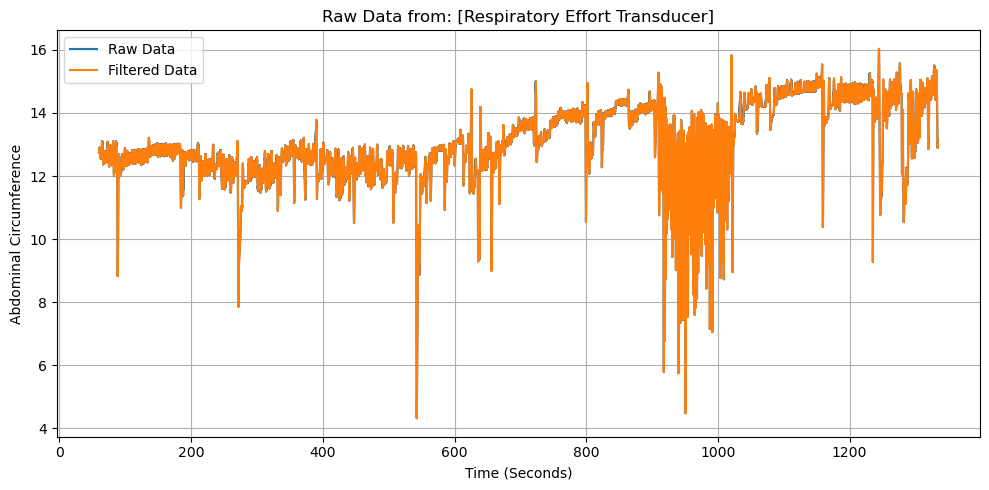

In [36]:
# Load the CSV file into a NumPy array
data = pd.read_csv("C:\\Users\\brhei\\Downloads\\Ben_Testing_csv_4_19_2025.csv")
print(list(data.iloc[:10,0]))


# LEDAdataP = pd.read_csv('C:\\Users\\brhei\\Desktop\\PythonWork\\Realtime_Work\\Threaf&feature\\LiveDataLEDA.csv')
RSP_data = list(data.iloc[(60*2000):,0])
fs = 2000
cutoff = 5
nyquist = 0.5 * fs
normal_cutoff = cutoff / nyquist
b, a = butter(5, normal_cutoff, btype='low', analog=False)
filtered_data = filtfilt(b, a, RSP_data)


Rdata, info = nk.rsp_process(filtfilt(b, a, RSP_data), sampling_rate=2000, report="text")
print(len(Rdata['RSP_Rate']))
print(Rdata['RSP_Rate'])




# Adjust time axis to account for the removed first minute
time = np.arange((60 * 2000), len(data)) / 2000  # Adjust start to match remaining data

# Adjust x-axis to show minute markers
minute_ticks = np.arange(60, (len(Rdata) / 2000) + 1, 60)  # Start from minute 1, add markers every 60 seconds
minute_labels = [f"{int(t // 60)}" for t in minute_ticks]  # Labels as minutes
plt.xticks(minute_ticks * 2000, minute_labels)  # Scale ticks to match sampling rate

# Plot the data
plt.figure(figsize=(10, 5))
plt.plot(time, RSP_data, label='Raw Data')
plt.plot(time, filtered_data, label='Filtered Data')

# Add labels and title
plt.xlabel("Time (Seconds)")
plt.ylabel("Abdominal Circumference")
plt.title("Raw Data from: [Respiratory Effort Transducer]")
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.show()


# plt.figure()
# plt.plot(signals['RSP_Rate'], label='DataPart')
# plt.legend()

# plt.grid()
# plt.xlabel("Time [Seconds]")
# plt.ylabel("Respiration Rate")
# plt.title("Respiration Rate [Window=60s Stride = 1s]")
# plt.show()

In [103]:
# Define the baseline period: first 45 seconds at 2000 Hz
baseline_duration = 0                  # seconds
baseline_samples = 2000 * baseline_duration
baseline_segment = RSP_data[:baseline_samples]

# Parameters for batch processing
window_size = 2000 * 120                # 45-second window
step_size = 2000 * 1                    # Extract the last 1 second from each window

# Compute the number of batches using the remaining data after the baseline period
remaining_data_length = len(RSP_data) - baseline_samples
num_batches = (remaining_data_length - window_size) // step_size + 1

# Initialize an empty list to store features
features_list = []

# Iterate over each batch window
for i in range(num_batches):
    # Define the start and end indices for the current window
    start_idx = baseline_samples + i * step_size
    end_idx = start_idx + window_size
    batch_segment = RSP_data[start_idx:end_idx]

    # Concatenate the baseline with the current batch segment
    concatenated_b_segment = np.concatenate((baseline_segment, batch_segment))

    # Process the concatenated_b segment (with filtering)
    features, info = nk.rsp_process(
        filtfilt(b, a, concatenated_b_segment),
        sampling_rate=2000
    )
    processed_rate = list(features["RSP_Rate"])

    # Append only the last step_size portion to avoid overlap duplication
    features_list.append(processed_rate[-step_size:])

# Concatenate all processed pieces
concatenated_b_features = np.concatenate(features_list)
print("Done with Batch examination . . .")
concatenated_b = np.concatenate(features_list)
temp = Rdata['RSP_Rate']
print(len(temp[window_size:]))
print(len(concatenated_b))
df = pd.DataFrame(concatenated_b)

# Save as CSV:
# - index=False omits the row indices,
# - header=False omits any header row.
df.to_csv("[120_1]_LIFO.csv", index=False, header=False)

Done with Batch examination . . .
2308908
2310000


In [51]:
df = pd.DataFrame(concatenated_b)

# Save as CSV:
# - index=False omits the row indices,
# - header=False omits any header row.
df.to_csv("[45_1]_LIFO.csv", index=False, header=False)


2310000


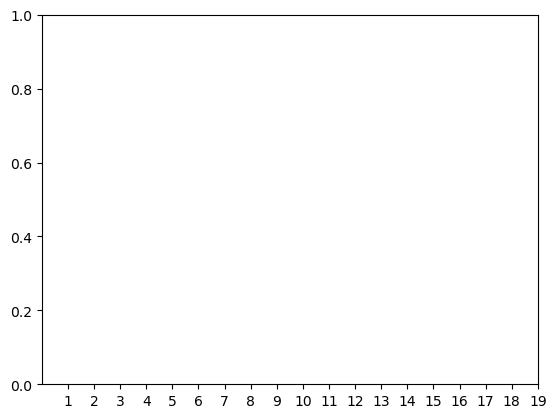

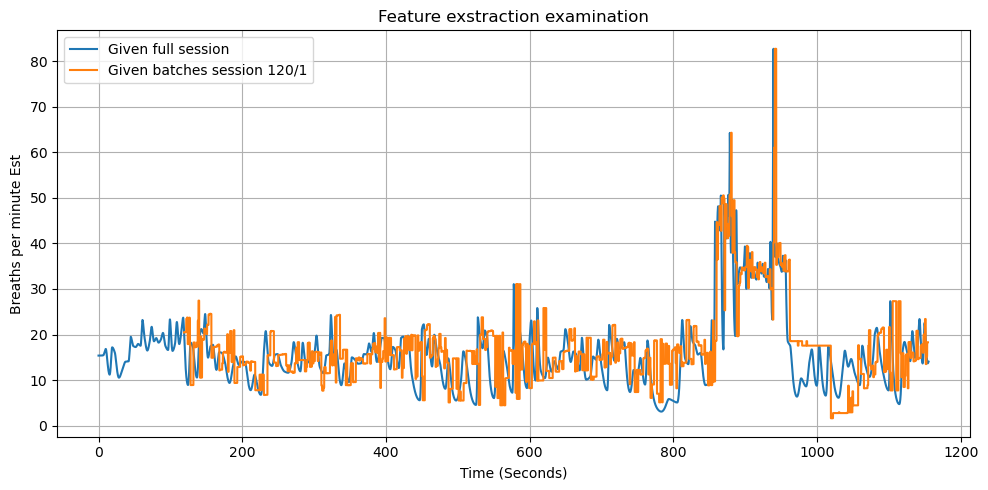

In [109]:
# Adjust time axis to account for the removed first minute
time = np.arange(len(concatenated_b)) / 2000  # Match time length to concatenated_b array

# Adjust x-axis to show minute markers
minute_ticks = np.arange(60, (len(time) / 2000) + 1, 60)  # Start from minute 1, add markers every 60 seconds
minute_labels = [f"{int(t // 60)}" for t in minute_ticks]  # Labels as minutes
plt.xticks(minute_ticks * 2000, minute_labels)  # Scale ticks to match sampling rate

# Ensure consistent lengths for plotting
min_length = min(len(time), len(concatenated_b))
time = time[:min_length]

time_b = np.arange(len(concatenated_b)) / 2000  # Match time length to concatenated_b array
min_length_b = min(len(time_b), len(concatenated_b))
time_b = time[:min_length_b]
concatenated_b = concatenated_b[:min_length_b]

time_b = np.arange(len(concatenated_b)) / 2000  # Match time length to concatenated_b array
min_length_b = min(len(time_b), len(concatenated_b))
time_b = time[:min_length_b]
concatenated_b = concatenated_b[:min_length_b]

# Directly reduce "Given full session" size from the beginning
RSP_Rate = Rdata["RSP_Rate"][:min_length]  # Trim to match the reduced size

# Plot the data
plt.figure(figsize=(10, 5))
# plt.plot(time, concatenated, label="batches 45/1")

# plt.plot(time_b, concatenated_b, label="Given batches session 45/10")
plt.plot(time, RSP_Rate, label="Given full session")
plt.plot(time_b[0:min_length-(2000*120)]+119, concatenated_b[0:min_length-(2000*120)], label="Given batches session 120/1")



# Add labels and title
plt.xlabel("Time (Seconds)")
plt.ylabel("Breaths per minute Est")
plt.title("Feature exstraction examination")
plt.grid(True)
plt.legend()
plt.tight_layout()
print(len(time_b))
plt.show()

In [ ]:
# Define the baseline period: first 45 seconds at 2000 Hz
baseline_duration = 45                  # seconds
baseline_samples = 2000 * baseline_duration
baseline_segment = RSP_data[:baseline_samples]

# Parameters for batch processing
window_size = 2000 * 45                # 45-second window
step_size = 2000                       # Extract the last 1 second from each window

# Compute the number of batches using the remaining data after the baseline period
remaining_data_length = len(RSP_data) - baseline_samples
num_batches = (remaining_data_length - window_size) // step_size + 1

# Initialize an empty list to store features
features_list = []

# Iterate over each batch window
for i in range(num_batches):
    # Define the start and end indices for the current window
    start_idx = baseline_samples + i * step_size
    end_idx = start_idx + window_size
    batch_segment = RSP_data[start_idx:end_idx]

    # Concatenate the baseline with the current batch segment

    # Process the concatenated_b segment (with filtering)
    features, info = nk.rsp_process(
        filtfilt(b, a, batch_segment),
        sampling_rate=2000
    )
    processed_rate = list(features["RSP_Rate"])

    # Append only the last step_size portion to avoid overlap duplication
    features_list.append(processed_rate[-step_size:])

# Concatenate all processed pieces
concatenated_b_features = np.concatenate(features_list)
print("Done with Batch examination . . .")
concatenated_b = np.concatenate(features_list)
temp = Rdata['RSP_Rate']
print(len(temp[window_size:]))
print(len(concatenated_b))
np.savetxt("LIFO.csv", concatenated_b, delimiter=",", fmt="%s")

In [ ]:
# Adjust time axis to account for the removed first minute
time = np.arange(len(concatenated_b)) / 2000  # Match time length to concatenated_b array

# Adjust x-axis to show minute markers
minute_ticks = np.arange(60, (len(time) / 2000) + 1, 60)  # Start from minute 1, add markers every 60 seconds
minute_labels = [f"{int(t // 60)}" for t in minute_ticks]  # Labels as minutes
plt.xticks(minute_ticks * 2000, minute_labels)  # Scale ticks to match sampling rate

# Ensure consistent lengths for plotting
min_length = min(len(time), len(concatenated_b))
time = time[:min_length]
concatenated_b = concatenated_b[:min_length]

# Directly reduce "Given full session" size from the beginning
RSP_Rate = Rdata["RSP_Rate"][:min_length]  # Trim to match the reduced size

# Plot the data
plt.figure(figsize=(10, 5))
plt.plot(time, concatenated_b, label="Given batches session")
plt.plot(time, RSP_Rate, label="Given full session")

# Add labels and title
plt.xlabel("Time (Seconds)")
plt.ylabel("Abdominal Circumference")
plt.title("Raw Data from: [Respiratory Effort Transducer]")
plt.grid(True)
plt.legend()
plt.tight_layout()
`
plt.show()

In [ ]:
# Define the baseline period: first 45 seconds at 2000 Hz
baseline_duration = 45                  # seconds
baseline_samples = 2000 * baseline_duration
baseline_segment = RSP_data[:baseline_samples]

# Parameters for batch processing
window_size = 2000 * 45                # 45-second window
step_size = 2000                       # Extract the last 1 second from each window

# Compute the number of batches using the remaining data after the baseline period
remaining_data_length = len(RSP_data) - baseline_samples
num_batches = (remaining_data_length - window_size) // step_size + 1

# Initialize an empty list to store features
features_list = []

# Iterate over each batch window
for i in range(num_batches):
    # Define the start and end indices for the current window
    start_idx = baseline_samples + i * step_size
    end_idx = start_idx + window_size
    batch_segment = RSP_data[start_idx:end_idx]
    
    # Process the concatenated_b segment (with filtering)
    features, info = nk.rsp_process(
        filtfilt(b, a, concatenated_b_segment),
        sampling_rate=2000
    )
    processed_rate = list(features["RSP_Rate"])

    # Append only the last step_size portion to avoid overlap duplication
    features_list.append(processed_rate[-step_size:])

# Concatenate all processed pieces
concatenated_b_features = np.concatenate(features_list)
print("Done with Batch examination . . .")

In [ ]:
concatenated_b = np.concatenate(features_list)
temp = Rdata['RSP_Rate']
print(len(temp[window_size:]))
print(len(concatenated_b))
np.savetxt("LIFO.csv", concatenated_b, delimiter=",", fmt="%s")


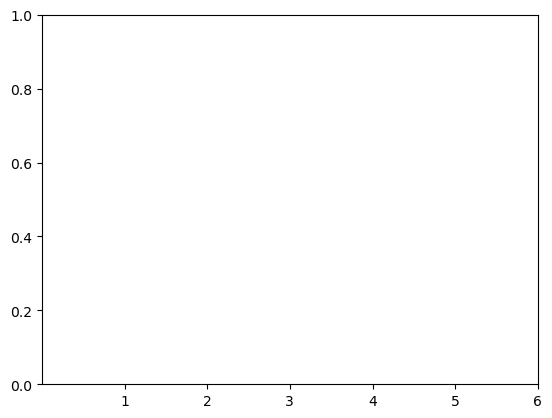

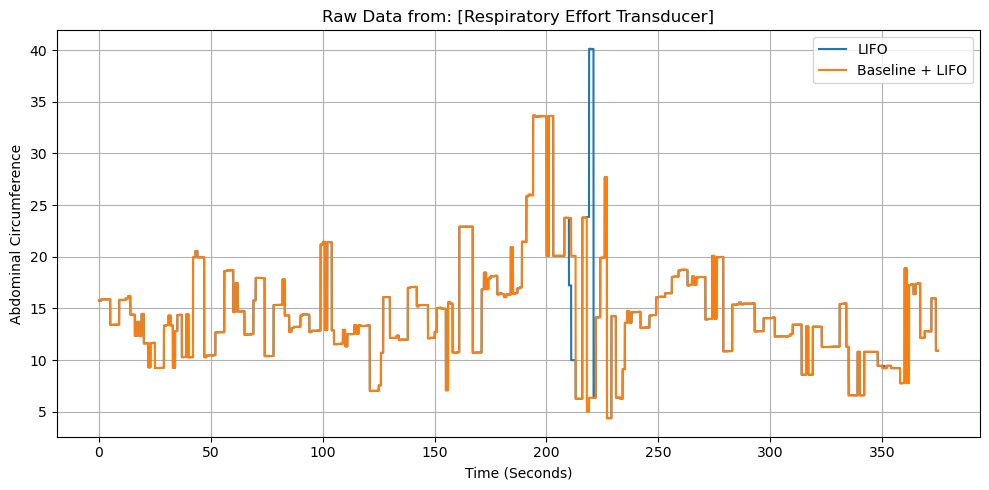

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the CSV files into DataFrames
lifo_data = pd.read_csv("C:\\Users\\brhei\\Desktop\\PythonWork\\Realtime_Work\\Threaf&feature\\LIFO.csv")
baseline_lifo_data = pd.read_csv("C:\\Users\\brhei\\Desktop\\PythonWork\\Realtime_Work\\Threaf&feature\\Baseline_LIFO.csv")

# Assuming both CSVs have 'Time' and 'Value' columns, adjust if column names differ

value_lifo = lifo_data

value_baseline = baseline_lifo_data

# Adjust the time axis to account for the removed first minute
time = np.arange(len(value_lifo)) / 2000  # Assuming sampling rate of 2000 Hz

# Adjust x-axis to show minute markers
minute_ticks = np.arange(60, (len(time) / 2000) + 1, 60)  # Start from minute 1, add markers every 60 seconds
minute_labels = [f"{int(t // 60)}" for t in minute_ticks]  # Labels as minutes
plt.xticks(minute_ticks * 2000, minute_labels)  # Scale ticks to match sampling rate

# Ensure consistent lengths for plotting
min_length = min(len(time), len(value_lifo), len(value_baseline))  # Trim all data to the same size
time = time[:min_length]
value_lifo = value_lifo[:min_length]
value_baseline = value_baseline[:min_length]

# Plot the data
plt.figure(figsize=(10, 5))
plt.plot(time, value_lifo, label="LIFO")
plt.plot(time, value_baseline, label="Baseline + LIFO")


# Add labels and title
plt.xlabel("Time (Seconds)")
plt.ylabel("Abdominal Circumference")
plt.title("Raw Data from: [Respiratory Effort Transducer]")
plt.grid(True)
plt.legend()
plt.tight_layout()

# Show the plot
plt.show()

In [58]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.pyplot as plt

# Load the CSV files into DataFrames
lifo_data = pd.read_csv("Desktop/PythonWork/Realtime_Work/Threaf&feature/LIFO.csv")
baseline_lifo_data = pd.read_csv("Desktop/PythonWork/Realtime_Work/Threaf&feature/Baseline_LIFO.csv")

# Assuming both CSVs have a 'Time' column and a 'Value' column, adjust if different
time_lifo = lifo_data['Time']
value_lifo = lifo_data['Value']
time_baseline = baseline_lifo_data['Time']
value_baseline = baseline_lifo_data['Value']

# Plot the data
plt.figure(figsize=(10, 6))
plt.plot(time_lifo, value_lifo, label="LIFO", color="blue", linewidth=2)
plt.plot(time_baseline, value_baseline, label="Baseline + LIFO", color="red", linestyle="--", linewidth=2)

# Add labels, title, and legend
plt.xlabel("Time")
plt.ylabel("Value")
plt.title("LIFO vs Baseline + LIFO")
plt.legend()
plt.grid(True)

# Show the plot
plt.show()
# Adjust time axis to account for the removed first minute
time = np.arange(len(concatenated_b)) / 2000  # Match time length to concatenated_b array

# Adjust x-axis to show minute markers
minute_ticks = np.arange(60, (len(time) / 2000) + 1, 60)  # Start from minute 1, add markers every 60 seconds
minute_labels = [f"{int(t // 60)}" for t in minute_ticks]  # Labels as minutes
plt.xticks(minute_ticks * 2000, minute_labels)  # Scale ticks to match sampling rate

# Ensure consistent lengths for plotting
min_length = min(len(time), len(concatenated_b))
time = time[:min_length]
concatenated_b = concatenated_b[:min_length]

# Directly reduce "Given full session" size from the beginning
RSP_Rate = Rdata["RSP_Rate"][:min_length]  # Trim to match the reduced size

# Plot the data
plt.figure(figsize=(10, 5))
plt.plot(time, concatenated_b, label="Given batches session")
plt.plot(time, RSP_Rate, label="Given full session")

# Add labels and title
plt.xlabel("Time (Seconds)")
plt.ylabel("Abdominal Circumference")
plt.title("Raw Data from: [Respiratory Effort Transducer]")
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'Desktop/PythonWork/Realtime_Work/Threaf&feature/LIFO.csv'

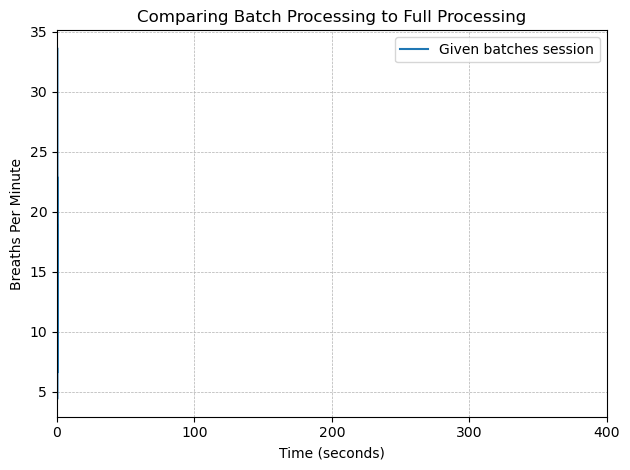

In [15]:
plt.figure()

# Create a time axis in seconds for the batch-processed data
time_batches = (np.array([i + window_size - step_size for i in range(len(concatenated_b))])) / 2000.0

# Create a time axis in seconds for the full session data
time_full = np.arange(len(Rdata["RSP_Rate"])) / 2000.0

# Plot the batch session (x-axis in seconds)
plt.plot(time_batches, concatenated_b, label="Given batches session")

# Plot the full session (x-axis in seconds)
# plt.plot(time_full, Rdata["RSP_Rate"], label="Given full session")

# Calculate total duration in seconds based on full session data
total_seconds = len(Rdata["RSP_Rate"]) / 2000.0

# Define tick marks on the x-axis at every 100 seconds
sec_ticks = np.arange(0, total_seconds + 1, 100)  # Create ticks every 100 seconds
plt.xticks(sec_ticks * 2000, [f"{int(t)}" for t in sec_ticks])  # Convert ticks to sample indices

# Add labels, legend, and title
plt.xlabel("Time (seconds)")
plt.ylabel("Breaths Per Minute")
plt.title("Comparing Batch Processing to Full Processing")
plt.legend()

# Customize grid lines
plt.grid(which="both", linestyle="--", linewidth=0.5)
plt.grid(which="minor", linestyle=":", color="gray", linewidth=0.3)

plt.tight_layout()
plt.show()

In [17]:
window_size = 2000*60  # Adjust this value; Keep in mind that biopac collects data at 2000 hz so 20,000 data points means 10 seconds
step = 20000          # Adjust this value
arry_bvg_R = []
arry_max_R = []
arry_min_R = []
arry_bvg_b = []
arry_max_b = []
arry_min_b = []

arry_bvg_R_F = []
arry_max_R_F = []
arry_min_R_F = []
arry_bvg_b_F = []
arry_max_b_F = []
arry_min_b_F = []

# Change to minutes: 

# Assuming data is a list or an array
num_windows = (len(data) - window_size) // step + 1

for i in range(num_windows):
    start = i * step
    end = start + window_size
    # Process your window here
    signals, info = nk.rsp_process(filtfilt(b, a, RSP_data[start:end]), sampling_rate=2000)
    tmp  = list(signals['RSP_Rate'])
    arry_bvg_R_F.extend(tmp[0:step])

# Using range() to create a range of numbers from 0 to len(ECG_data) with a step of 10
x = range(0, len(RSP_data), 10)
x = RSP_data.iloc[x]  # Convert to a list if needed
# # Plot the signals
# print(list(x))
plt.figure()
# plt.plot(RSP_data[::1000], label='raw')

plt.plot(arry_bvg_R_F, label='butterDataPart')
# plt.plot(signals['RSP_Rate'], label='new')

# plt.plot(RSP_data, label='Raw')

# plt.plot(arry_max_R, label='Neurokit')

# plt.plot( list(x),label='EDA (Microsiemens)')
# plt.plot(range(len(data_mat['arry avg T'])),arry_bvg_P[0:len(data_mat['arry avg T'])], label='Neurokit')
# plt.plot(range(len(data_mat['arry avg T'])),data_mat['arry avg T'], label='LedaLabs')
# plt.plot(range(len(data_mat['arry avg T'])), nhold[0:len(data_mat['arry avg T'])], label='Raw')
# plt.plot(processed_2, label="Unique EDA", linewidth = 3)

plt.legend()

plt.grid()
plt.xlabel("Time [Seconds]")
plt.ylabel("Respiration Rate")
plt.title("Respiration Rate [Window=60s Stride = 1s]")

plt.legend()
plt.show()

C:\Users\brhei\anaconda3\Lib\site-packages\neurokit2\signal\signal_period.py:84: NeuroKitWarning: Too few peaks detected to compute the rate. Returning empty vector.
  warn(
C:\Users\brhei\anaconda3\Lib\site-packages\neurokit2\rsp\rsp_symmetry.py:90: NeuroKitWarning: Not enough peaks and troughs (signal too short?) to compute symmetry, returning nan for symmetry.
  warn(
C:\Users\brhei\anaconda3\Lib\site-packages\neurokit2\signal\signal_period.py:84: NeuroKitWarning: Too few peaks detected to compute the rate. Returning empty vector.
  warn(
C:\Users\brhei\anaconda3\Lib\site-packages\neurokit2\rsp\rsp_symmetry.py:90: NeuroKitWarning: Not enough peaks and troughs (signal too short?) to compute symmetry, returning nan for symmetry.
  warn(


IndexError: index 1 is out of bounds for axis 0 with size 1

In [30]:
plt.show()

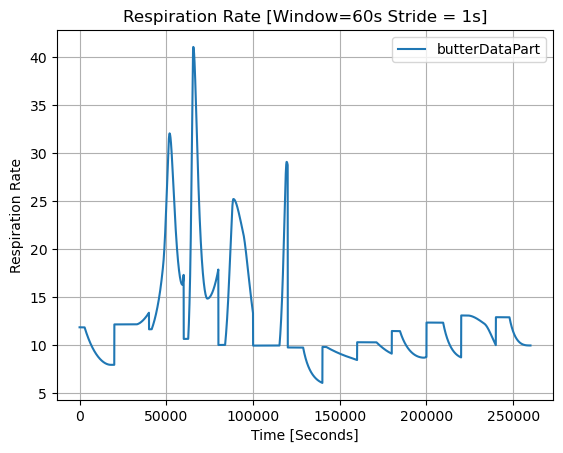

In [29]:
window_size = 2000*60*3  # Adjust this value; Keep in mind that biopac collects data at 2000 hz so 20,000 data points means 10 seconds
step = 20000          # Adjust this value
arry_bvg_R = []
arry_max_R = []
arry_min_R = []
arry_bvg_b = []
arry_max_b = []
arry_min_b = []

arry_bvg_R_F = []
arry_max_R_F = []
arry_min_R_F = []
arry_bvg_b_F = []
arry_max_b_F = []
arry_min_b_F = []

# Change to minutes: 

# Assuming data is a list or an array
num_windows = (len(data) - window_size) // step + 1

for i in range(num_windows):
    start = i * step
    end = start + window_size
    # Process your window here
    signals, info = nk.rsp_process(filtfilt(b, a, RSP_data[start:end]), sampling_rate=2000)
    tmp  = list(signals['RSP_Rate'])
    arry_bvg_R_F.extend(tmp[0:step])

# Using range() to create a range of numbers from 0 to len(ECG_data) with a step of 10
x = range(0, len(RSP_data), 10)
x = RSP_data.iloc[x]  # Convert to a list if needed
# # Plot the signals
# print(list(x))
plt.figure()
# plt.plot(RSP_data[::1000], label='raw')

plt.plot(arry_bvg_R_F, label='butterDataPart')
# plt.plot(signals['RSP_Rate'], label='new')

# plt.plot(RSP_data, label='Raw')

# plt.plot(arry_max_R, label='Neurokit')

# plt.plot( list(x),label='EDA (Microsiemens)')
# plt.plot(range(len(data_mat['arry avg T'])),arry_bvg_P[0:len(data_mat['arry avg T'])], label='Neurokit')
# plt.plot(range(len(data_mat['arry avg T'])),data_mat['arry avg T'], label='LedaLabs')
# plt.plot(range(len(data_mat['arry avg T'])), nhold[0:len(data_mat['arry avg T'])], label='Raw')
# plt.plot(processed_2, label="Unique EDA", linewidth = 3)

plt.legend()

plt.grid()
plt.xlabel("Time [Seconds]")
plt.ylabel("Respiration Rate")
plt.title("Respiration Rate [Window=60s Stride = 1s]")

plt.legend()
plt.show()

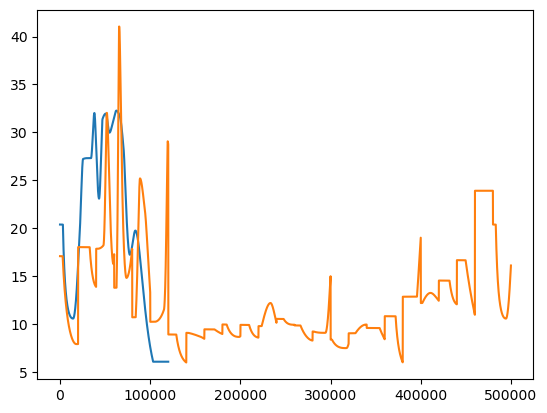

In [41]:
plt.figure()
plt.plot(signals['RSP_Rate'], label='DataPart')
plt.plot(arry_bvg_R_F, label='butterDataPart')